In [33]:
import numpy as np
import cv2
import kornia
import torch


def horizontal_flip_img(imgs: torch.Tensor):
    '''
    imgs: [B,C,H,W]
    '''
    return torch.flip(imgs, dims=[3])

def rotate_img(imgs: torch.Tensor, degree: torch.Tensor):
    '''
    imgs: [B,C,H,W]
    degree: [B]
    '''
    center = torch.tensor([imgs.shape[2] / 2, imgs.shape[3] / 2], device=imgs.device).repeat(imgs.size(0), 1)
    M = kornia.geometry.transform.get_rotation_matrix2d(center, degree, torch.ones_like(center))
    rotated_imgs = kornia.geometry.transform.warp_affine(imgs, M, (imgs.shape[2], imgs.shape[3]))
    return rotated_imgs

def hflip_rotate_img(imgs: torch.Tensor, degree: torch.Tensor):
    '''
    imgs: [B,C,H,W]
    degree: [B]
    '''
    flipped_imgs = horizontal_flip_img(imgs)
    rotated_flipped_imgs = rotate_img(flipped_imgs, degree)
    return rotated_flipped_imgs

In [35]:
img = cv2.imread("data/Imagenet-1K/train/n01443537/n01443537_10035.JPEG")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = torch.from_numpy(img) / 255.

In [30]:
torch.ones_like(torch.tensor([30.])).repeat(2)[None,...].shape

torch.Size([1, 2])

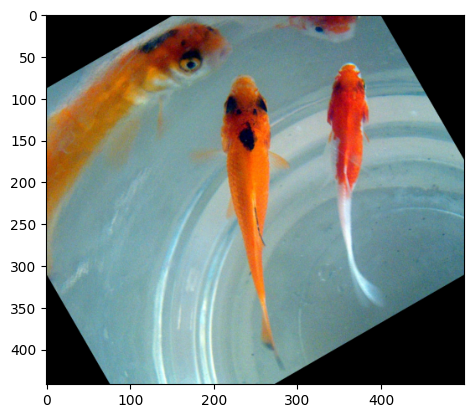

In [41]:
import einops as eps
img_tensor = eps.rearrange(img, 'h w c -> c h w')

flipped = horizontal_flip_img(img_tensor[None,...])[0]
flipped = eps.rearrange(flipped, 'c h w -> h w c')
# plt.imshow(flipped)

rotated = rotate_img(img_tensor[None,...], degree=torch.tensor([30.]))[0]
rotated = eps.rearrange(rotated, 'c h w -> h w c')
# plt.imshow(rotated)

flip_rotated = hflip_rotate_img(img_tensor[None,...], degree=torch.tensor([30.]))[0]
flip_rotated = eps.rearrange(flip_rotated, 'c h w -> h w c')
# plt.imshow(flip_rotated)

In [10]:
img.shape

torch.Size([442, 500, 3])